
TASK 1: DATA PREPARATION
Dataset shape: (20631, 26)
Number of engines: 100

TASK 2: MODEL IMPLEMENTATION

[Task 2.1] Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1020
           1       0.61      0.60      0.61      1500
           2       0.72      0.76      0.74      1607

    accuracy                           0.71      4127
   macro avg       0.73      0.72      0.73      4127
weighted avg       0.72      0.71      0.71      4127


[Task 2.2] Random Forest
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1020
           1       0.65      0.58      0.61      1500
           2       0.70      0.82      0.76      1607

    accuracy                           0.73      4127
   macro avg       0.75      0.74      0.74      4127
weighted avg       0.73      0.73      0.73      4127


[Task 2.3] KNN
              precision    recall  f1-score   support

   

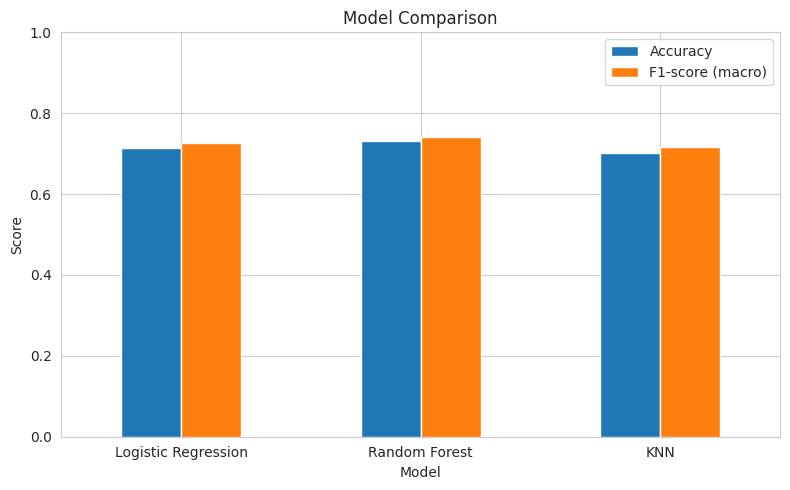

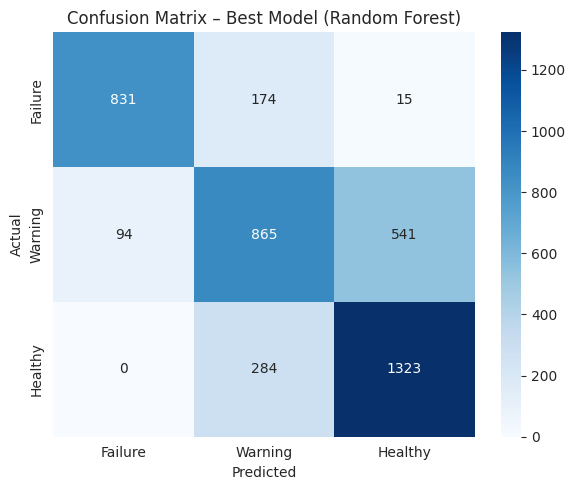


Top 10 Feature Importances (Random Forest)
      Feature  Importance
13  sensor_11    0.144958
6    sensor_4    0.113984
11   sensor_9    0.099318
14  sensor_12    0.097394
16  sensor_14    0.080774
9    sensor_7    0.077729
17  sensor_15    0.065537
23  sensor_21    0.062585
22  sensor_20    0.059602
4    sensor_2    0.038600


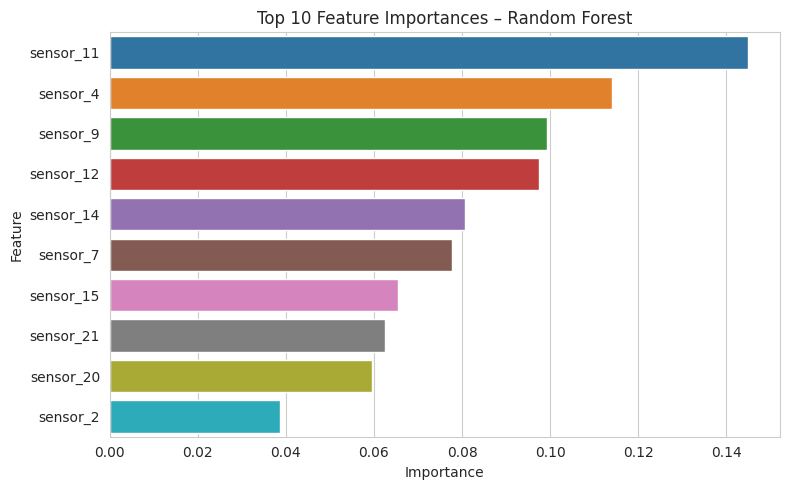

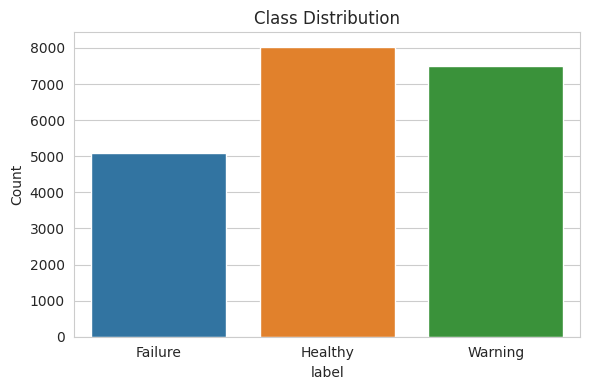

In [1]:
# ============================================================
# CMAPSS CLASSIFICATION PROJECT – FD001
# Healthy / Warning / Failure Imminent
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# ============================================================
# TASK 1: DATA PREPARATION
# ============================================================
print("\n" + "="*80)
print("TASK 1: DATA PREPARATION")
print("="*80)

DATA_PATH = '/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt'

columns = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

df = pd.read_csv(DATA_PATH, sep='\s+', header=None)
df.columns = columns

print("Dataset shape:", df.shape)
print("Number of engines:", df.engine_id.nunique())

# ---- RUL computation
max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

df = df.merge(max_cycle, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop(columns='max_cycle', inplace=True)

# ---- Label definition
def assign_label(rul):
    if rul <= 50:
        return 0      # Failure
    elif rul <= 125:
        return 1      # Warning
    else:
        return 2      # Healthy

df['label'] = df['RUL'].apply(assign_label)

# ---- Train / Test split
X = df.drop(columns=['engine_id', 'cycle', 'RUL', 'label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# TASK 2: MODEL IMPLEMENTATION
# ============================================================
print("\n" + "="*80)
print("TASK 2: MODEL IMPLEMENTATION")
print("="*80)

models = {}
predictions = {}

# ------------------------------------------------------------
# 2.1 Logistic Regression
# ------------------------------------------------------------
print("\n[Task 2.1] Logistic Regression")

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {'C': [0.01, 0.1, 1, 10]},
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = grid_lr.best_estimator_
predictions['Logistic Regression'] = models['Logistic Regression'].predict(X_test_scaled)

print(classification_report(y_test, predictions['Logistic Regression']))

# ------------------------------------------------------------
# 2.2 Random Forest
# ------------------------------------------------------------
print("\n[Task 2.2] Random Forest")

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [100, 200],
        'max_depth': [8, 10, 12]
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
models['Random Forest'] = grid_rf.best_estimator_
predictions['Random Forest'] = models['Random Forest'].predict(X_test)

print(classification_report(y_test, predictions['Random Forest']))

# ------------------------------------------------------------
# 2.3 KNN
# ------------------------------------------------------------
print("\n[Task 2.3] KNN")

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9]},
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)
models['KNN'] = grid_knn.best_estimator_
predictions['KNN'] = models['KNN'].predict(X_test_scaled)

print(classification_report(y_test, predictions['KNN']))

# ============================================================
# TASK 3: EVALUATION AND ANALYSIS
# ============================================================
print("\n" + "="*80)
print("TASK 3: EVALUATION AND ANALYSIS")
print("="*80)

# ---- Metrics table
results = []
for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_test, y_pred, average='macro')
    })

results_df = pd.DataFrame(results)
print(results_df)

# ---- Model comparison plot
results_df.set_index('Model')[['Accuracy','F1-score (macro)']].plot(
    kind='bar', figsize=(8,5), rot=0
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# ---- Best model confusion matrix (highest F1-macro)
best_model_name = results_df.sort_values('F1-score (macro)', ascending=False).iloc[0]['Model']
best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Failure','Warning','Healthy'],
    yticklabels=['Failure','Warning','Healthy']
)
plt.title(f'Confusion Matrix – Best Model ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ---- Feature importance (Random Forest)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Feature Importances (Random Forest)")
print(importance_df.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances – Random Forest')
plt.tight_layout()
plt.show()

# ---- Class distribution 
label_map = {0:'Failure', 1:'Warning', 2:'Healthy'}
class_counts = y.map(label_map).value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

